**Rahul Malani - 23070521088**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.9399 - loss: 0.1961 - val_accuracy: 0.9778 - val_loss: 0.0743
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9834 - loss: 0.0541 - val_accuracy: 0.9893 - val_loss: 0.0390
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9886 - loss: 0.0367 - val_accuracy: 0.9883 - val_loss: 0.0430
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.9910 - loss: 0.0285 - val_accuracy: 0.9892 - val_loss: 0.0376
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9932 - loss: 0.0214 - val_accuracy: 0.9893 - val_loss: 0.0401

Test Loss: 0.033524222671985626
Test Accuracy: 0.9894000291824341


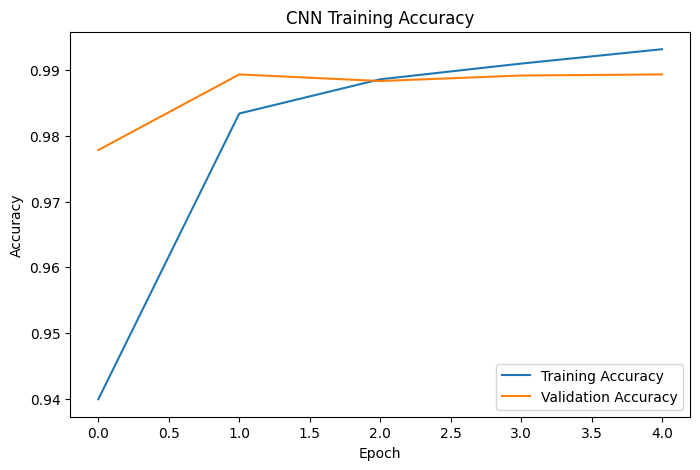

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


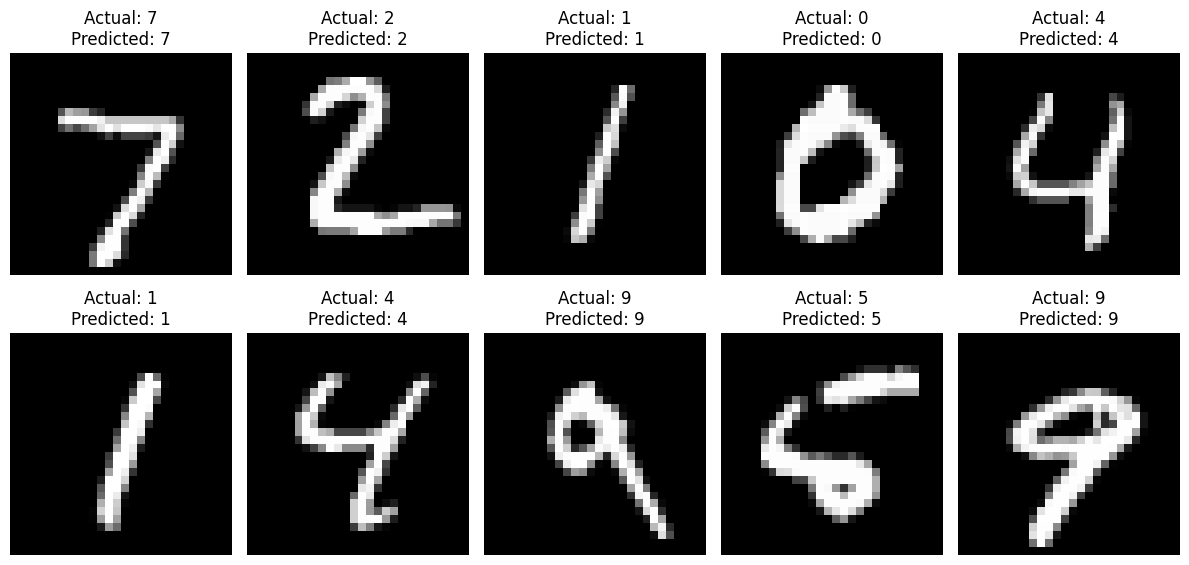


Model saved as mnist_cnn_model.keras


In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# 1. Load MNIST Dataset
# --------------------------------------------------
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# --------------------------------------------------
# 2. Preprocess the Data
# --------------------------------------------------
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension: (28, 28) -> (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
# --------------------------------------------------
# 3. Build CNN Architecture
# --------------------------------------------------
model = models.Sequential([
    # Convolution Layer
    layers.Conv2D(32, (3, 3), activation="relu",
                  input_shape=(28, 28, 1)),
    # Pooling Layer
    layers.MaxPooling2D((2, 2)),
    # Second Convolution Layer
    layers.Conv2D(64, (3, 3), activation="relu"),
    # Second Pooling Layer
    layers.MaxPooling2D((2, 2)),
    # Third Convolution Layer
    layers.Conv2D(64, (3, 3), activation="relu"),
    # Flatten
    layers.Flatten(),
    # Fully Connected Layer
    layers.Dense(64, activation="relu"),
    # Output Layer - 10 digits (0-9)
    layers.Dense(10, activation="softmax")
])
# Display model architecture
model.summary()
# --------------------------------------------------
# 4. Compile the Model
# --------------------------------------------------
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --------------------------------------------------
# 5. Train the CNN Model
# --------------------------------------------------
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

# --------------------------------------------------
# 6. Evaluate the Model
# --------------------------------------------------
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# --------------------------------------------------
# 7. Display Training Accuracy
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# --------------------------------------------------
# 8. Display Sample Predictions
# --------------------------------------------------
predictions = model.predict(x_test)

plt.figure(figsize=(12, 6))

for i in range(10):
    predicted_digit = np.argmax(predictions[i])

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {predicted_digit}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 9. Save the Trained Model
# --------------------------------------------------
model.save("mnist_cnn_model.keras")
print("\nModel saved as mnist_cnn_model.keras")